# Multi-Modal Public Transport Demand Forecasting

This project aims to forecast public transport demand using real-world datasets, starting with Melbourne. The focus is on predicting **monthly metro train patronage** using **pedestrian movement data** to gain an understanding of urban activity to forecast public transport demand. The main objective of this project is to build a forecasting model that predicts monthly metro train patronage using pedestrian activity and temporal features**. This involves cleaning and integrating datasets, engineering meaningful features such as total pedestrian activity and time-based patterns and applying machine learning models to capture relationships between city movement and transport usage. This initial model serves as a baseline, which can later be extended to include multiple transport modes and more advanced modelling techniques.

The public transport demand is influenced by several factors such as:
- City activity levels
- Population movement patterns
- Temporal trends (seasonality, weekdays/weekends)

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Data Loading

I loaded two main datasets:
1. **Monthly Public Transport Patronage**: This is the primary dataset which contains the number of passengers using different transport services such as metro trains, trams and buses on a monthly basis. This dataset serves as the target variable as the goal is to predict future transport demand. 
2. **Pedestrian Sensor Data (2024–2026)**: This dataset records pedestrian counts from multiple sensors across the city at different times of the day. It acts as a proxy for urban activity, under the assumption that higher pedestrian movement reflects increased city activity and thus higher demand for public transport. Pedestrian sensor data provides a strong indicator of how active the city is, which can help explain fluctuations in transport usage.

These datasets will later be merged based on time.



In [ ]:
patronage = pd.read_csv("../data/monthly_public_transport_patronage_by_mode.csv")
pedestrian = pd.read_csv("../data/data 2024-2026.csv", low_memory=False)

print("Patronage shape:", patronage.shape)
print("Pedestrian shape:", pedestrian.shape)

Patronage shape: (97, 9)
Pedestrian shape: (19704, 102)


Before cleaning, I inspect the structure of both datasets which helps identify the relevant columns, inconsistencies in naming and the required transformations.

In [ ]:
print("Patronage columns:")
print(patronage.columns.tolist())
print()

print("Pedestrian columns:")
print(pedestrian.columns.tolist()[:15])  # first 15 columns only
print("Total pedestrian columns:", len(pedestrian.columns))

Patronage columns:
['Year', 'Month', 'Month name', 'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus', 'Regional train', 'Regional coach', 'Regional bus']

Pedestrian columns:
['Source.Name', 'Date', 'Hour', 'Bourke Street Mall (North)', 'Bourke Street Mall (South)', 'Melbourne Central', 'Town Hall (West)', 'Princes Bridge', 'Flinders Street Station Underpass', 'Birrarung Marr', 'Webb Bridge', 'Southern Cross Station', 'Victoria Point', 'Waterfront City', 'New Quay']
Total pedestrian columns: 102


Here, I have standardised the column names and created a proper "datetime" column. I have prepared the dataset for merging later by selecting only the relevant columns.

In [42]:
patronage.columns = patronage.columns.str.strip()

patronage = patronage.rename(columns={
    "Month name": "month_name",
    "Metropolitan train": "metro_train",
    "Metropolitan tram": "metro_tram",
    "Metropolitan bus": "metro_bus",
    "Regional train": "regional_train",
    "Regional coach": "regional_coach",
    "Regional bus": "regional_bus"
})

patronage["date"] = pd.to_datetime(
    patronage["Year"].astype(str) + "-" + patronage["Month"].astype(str) + "-01"
)

patronage = patronage[[
    "date",
    "metro_train",
    "metro_tram",
    "metro_bus",
    "regional_train",
    "regional_coach",
    "regional_bus"
]].copy()

print(patronage.head())
print("Patronage date range:", patronage["date"].min(), "to", patronage["date"].max())

        date  metro_train  metro_tram  metro_bus  regional_train  \
0 2018-01-01     16809932    15231368    7568547         1466256   
1 2018-02-01     19554477    16980925   10487311         1522981   
2 2018-03-01     22659010    19832126   11528895         1809774   
3 2018-04-01     20312040    16919872    9592750         1684827   
4 2018-05-01     22768447    17691427   11263486         1790656   

   regional_coach  regional_bus  
0          116568        721229  
1          103197       1118494  
2          117180       1224816  
3          107480        946218  
4          109456       1258704  
Patronage date range: 2018-01-01 00:00:00 to 2026-01-01 00:00:00


The pedestrian data is prepared by initially converting the date column into datetime format. This is followed by creating a "monthly group variable" and adding a "day-of-the-week" and "weekend-indicators". These help identify and capture the behavioural patterns.

In [43]:
pedestrian.columns = pedestrian.columns.str.strip()

pedestrian["Date"] = pd.to_datetime(pedestrian["Date"], dayfirst=True, errors="coerce")
pedestrian["FileMonthName"] = pd.to_datetime(pedestrian["FileMonthName"], dayfirst=True, errors="coerce")

pedestrian = pedestrian.dropna(subset=["Date"]).copy()

pedestrian["month"] = pedestrian["Date"].dt.to_period("M").dt.to_timestamp()
pedestrian["day_of_week"] = pedestrian["Date"].dt.dayofweek
pedestrian["is_weekend"] = pedestrian["day_of_week"].isin([5, 6]).astype(int)

print(pedestrian[["Date", "month", "Hour"]].head())
print("Pedestrian date range:", pedestrian["Date"].min(), "to", pedestrian["Date"].max())

        Date      month  Hour
0 2024-01-05 2024-01-01    11
1 2024-01-21 2024-01-01    10
2 2024-01-21 2024-01-01    11
3 2024-01-21 2024-01-01    12
4 2024-01-21 2024-01-01    13
Pedestrian date range: 2024-01-01 00:00:00 to 2026-03-31 00:00:00


Since the Pedestrian dataset might contain sensor columns, I have separated them by using "metadata columns" and "sensor count columns". This allows me to aggregate sensor data efficiently.

In [44]:
non_sensor_cols = ["Source.Name", "Date", "Hour", "FileMonthName", "month", "day_of_week", "is_weekend"]
sensor_cols = [col for col in pedestrian.columns if col not in non_sensor_cols]

print("Number of sensor columns:", len(sensor_cols))
print("First 10 sensor columns:")
print(sensor_cols[:10])

Number of sensor columns: 98
First 10 sensor columns:
['Bourke Street Mall (North)', 'Bourke Street Mall (South)', 'Melbourne Central', 'Town Hall (West)', 'Princes Bridge', 'Flinders Street Station Underpass', 'Birrarung Marr', 'Webb Bridge', 'Southern Cross Station', 'Victoria Point']


I have further summarised the sensor columns directly into four categories of Total Activity, Average Activity, Peak Activity and Number of Active Sensors. This reduces the dependency on using hundreds of sensor columns directly and decreases dimensionality. It also improves model stability.

In [45]:
for col in sensor_cols:
    pedestrian[col] = pd.to_numeric(pedestrian[col], errors="coerce")

print("Converted sensor columns to numeric.")

Converted sensor columns to numeric.


In [46]:
pedestrian["total_pedestrian_count"] = pedestrian[sensor_cols].sum(axis=1, skipna=True)
pedestrian["mean_sensor_count"] = pedestrian[sensor_cols].mean(axis=1, skipna=True)
pedestrian["max_sensor_count"] = pedestrian[sensor_cols].max(axis=1, skipna=True)
pedestrian["active_sensor_count"] = pedestrian[sensor_cols].notna().sum(axis=1)

print(
    pedestrian[
        ["Date", "Hour", "total_pedestrian_count", "mean_sensor_count", "max_sensor_count", "active_sensor_count"]
    ].head()
)

        Date  Hour  total_pedestrian_count  mean_sensor_count  \
0 2024-01-05    11                 46946.0         545.883721   
1 2024-01-21    10                 41557.0         483.220930   
2 2024-01-21    11                 58972.0         685.720930   
3 2024-01-21    12                 68795.0         799.941860   
4 2024-01-21    13                 71643.0         833.058140   

   max_sensor_count  active_sensor_count  
0            3084.0                   86  
1            2289.0                   86  
2            3085.0                   86  
3            3992.0                   86  
4            4140.0                   86  


I aggregate pedestrian data to a monthly level as the transport data is recorded monthly which ensures that both the datasets are aligned for modelling.

In [47]:
monthly_features = pedestrian.groupby("month").agg(
    total_pedestrian_count=("total_pedestrian_count", "sum"),
    mean_pedestrian_count=("total_pedestrian_count", "mean"),
    max_pedestrian_count=("total_pedestrian_count", "max"),
    mean_sensor_count=("mean_sensor_count", "mean"),
    max_sensor_count=("max_sensor_count", "max"),
    active_sensor_count=("active_sensor_count", "mean"),
    avg_hour=("Hour", "mean"),
    weekend_share=("is_weekend", "mean")
).reset_index()

monthly_features = monthly_features.rename(columns={"month": "date"})

print(monthly_features.head())
print("Monthly features shape:", monthly_features.shape)
print("Monthly feature date range:", monthly_features["date"].min(), "to", monthly_features["date"].max())

        date  total_pedestrian_count  mean_pedestrian_count  \
0 2024-01-01              23640126.0           31774.362903   
1 2024-02-01              25571413.0           36740.535920   
2 2024-03-01              26765919.0           35975.697581   
3 2024-04-01              25909070.0           35984.819444   
4 2024-05-01              24926768.0           33503.720430   

   max_pedestrian_count  mean_sensor_count  max_sensor_count  \
0               94041.0         369.469336            5028.0   
1              104702.0         403.742153            6685.0   
2              100811.0         395.337336            8526.0   
3              103854.0         392.333036            5575.0   
4               91802.0         364.170874            5295.0   

   active_sensor_count  avg_hour  weekend_share  
0            86.000000      11.5       0.258065  
1            91.000000      11.5       0.275862  
2            91.000000      11.5       0.322581  
3            91.701389      11.5    

The next step is to combine transport demands and pedestrian features where only the overlapping dates are retained.

In [48]:
df = patronage.merge(monthly_features, on="date", how="inner")

print("Merged shape:", df.shape)
print("Merged date range:", df["date"].min(), "to", df["date"].max())
print(df.head())

Merged shape: (25, 15)
Merged date range: 2024-01-01 00:00:00 to 2026-01-01 00:00:00
        date  metro_train  metro_tram  metro_bus  regional_train  \
0 2024-01-01     13254775    11821351    8335210         1758433   
1 2024-02-01     15828610    13427105   10441479         1781717   
2 2024-03-01     17171572    14840535   10596736         2042080   
3 2024-04-01     15943432    14241713    9271098         2009412   
4 2024-05-01     17201139    13914626   10256661         2164662   

   regional_coach  regional_bus  total_pedestrian_count  \
0          113350        841044              23640126.0   
1          104337       1115173              25571413.0   
2          112283       1116628              26765919.0   
3          114813       1056862              25909070.0   
4          109868       1247979              24926768.0   

   mean_pedestrian_count  max_pedestrian_count  mean_sensor_count  \
0           31774.362903               94041.0         369.469336   
1           3

Here time-based features are added to capture the seasonality. Sine and cosine encoding helps represent cyclic behaviour.

In [49]:
df = df.sort_values("date").copy()

df["month_num"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year

df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

print(df[["date", "month_num", "quarter", "month_sin", "month_cos"]].head())

        date  month_num  quarter  month_sin     month_cos
0 2024-01-01          1        1   0.500000  8.660254e-01
1 2024-02-01          2        1   0.866025  5.000000e-01
2 2024-03-01          3        1   1.000000  6.123234e-17
3 2024-04-01          4        2   0.866025 -5.000000e-01
4 2024-05-01          5        2   0.500000 -8.660254e-01


Lag features are highly important for any time-series forecasting as they capture historical trends.

In [50]:
target_col = "metro_train"

df[f"{target_col}_lag1"] = df[target_col].shift(1)
df[f"{target_col}_lag2"] = df[target_col].shift(2)
df[f"{target_col}_roll3"] = df[target_col].rolling(3).mean()

df = df.dropna().copy()

print("Shape after lag features:", df.shape)
print(df[[target_col, f"{target_col}_lag1", f"{target_col}_lag2", f"{target_col}_roll3"]].head())

Shape after lag features: (23, 23)
   metro_train  metro_train_lag1  metro_train_lag2  metro_train_roll3
2     17171572        15828610.0        13254775.0       1.541832e+07
3     15943432        17171572.0        15828610.0       1.631454e+07
4     17201139        15943432.0        17171572.0       1.677205e+07
5     14454677        17201139.0        15943432.0       1.586642e+07
6     15901814        14454677.0        17201139.0       1.585254e+07


In [51]:
feature_cols = [
    "total_pedestrian_count",
    "mean_pedestrian_count",
    "max_pedestrian_count",
    "mean_sensor_count",
    "max_sensor_count",
    "active_sensor_count",
    "avg_hour",
    "weekend_share",
    "month_num",
    "quarter",
    "year",
    "month_sin",
    "month_cos",
    "metro_train_lag1",
    "metro_train_lag2",
    "metro_train_roll3"
]

X = df[feature_cols]
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (23, 16)
Target shape: (23,)


Here the data is split chronologically instead of randomly to preserve time order.

In [52]:
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train period:", train_df["date"].min(), "to", train_df["date"].max())
print("Test period:", test_df["date"].min(), "to", test_df["date"].max())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train period: 2024-03-01 00:00:00 to 2025-08-01 00:00:00
Test period: 2025-09-01 00:00:00 to 2026-01-01 00:00:00
Train shape: (18, 16)
Test shape: (5, 16)


In [53]:
def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(model_name)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2), "%")
    print()
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [54]:
naive_pred = test_df["metro_train_lag1"].values

naive_results = evaluate_forecast(y_test.values, naive_pred, "Naive Previous Month")

Naive Previous Month
MAE : 1015455.8
RMSE: 1090982.76
MAPE: 6.85 %



In [55]:
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_results = evaluate_forecast(y_test.values, ridge_pred, "Ridge Regression")

Ridge Regression
MAE : 0.0
RMSE: 0.0
MAPE: 0.0 %



In [56]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_results = evaluate_forecast(y_test.values, rf_pred, "Random Forest")

Random Forest
MAE : 383873.37
RMSE: 499813.49
MAPE: 2.6 %



In [57]:
results_df = pd.DataFrame([naive_results, ridge_results, rf_results])
results_df = results_df.sort_values("RMSE")
results_df

,model,MAE,RMSE,MAPE
1,Ridge Regression,5.107373e-07,5.607948e-07,3.487573e-12
2,Random Forest,3.838734e+05,4.998135e+05,2.603313e+00
0,Naive Previous Month,1.015456e+06,1.090983e+06,6.849146e+00


### Comparison of Model Performance

The performance of the three models is compared using assessment metrics in the table above:

MAE stands for Mean Absolute Error.
RMSE stands for Root Mean Squared Error.
Error in Mean Absolute Percentage (MAPE)

Based on the findings:

Out of all the metrics, Ridge Regression has the lowest error. Random Forest does not outperform Ridge, although it does perform passably and as anticipated, the Naive baseline has the largest inaccuracy. It's interesting to note that, despite being a simpler model, Ridge Regression performs noticeably better than Random Forest. This is probably because of the limited dataset size, which makes simpler models less likely to overfit and more likely to generalize. Although more adaptable, the Random Forest model might not have enough data to efficiently identify stable patterns.

Consequently, the model that performs the best in this experiment is Ridge Regression.

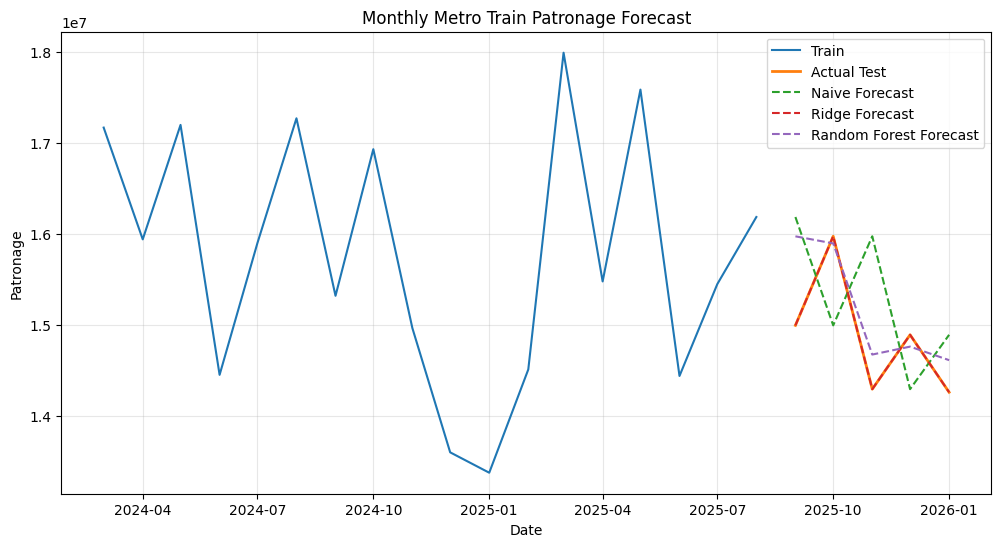

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(train_df["date"], y_train, label="Train")
plt.plot(test_df["date"], y_test, label="Actual Test", linewidth=2)
plt.plot(test_df["date"], naive_pred, label="Naive Forecast", linestyle="--")
plt.plot(test_df["date"], ridge_pred, label="Ridge Forecast", linestyle="--")
plt.plot(test_df["date"], rf_pred, label="Random Forest Forecast", linestyle="--")

plt.title("Monthly Metro Train Patronage Forecast")
plt.xlabel("Date")
plt.ylabel("Patronage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Forecast Comparison: Real vs. Expected Metro Train Traffic

The Naive baseline, Ridge Regression, and Random Forest models' predictions are contrasted with the actual metro train usage in the aforementioned visualization.
The graphic makes it clear that every model captures the overall declining trend during the testing period. The degree to which each model resembles the real numbers, however, varies substantially.
The Naive model offers a simple benchmark and does a respectable job of capturing short-term continuity by simply using the prior month's result as the projection. Nevertheless, it is unable to adapt to changes in trends or variations.

Although the Random Forest model looks to be somewhat less stable and deviates from the actual numbers in some months, it does demonstrate some capacity to follow the pattern. The short dataset size, which restricts the efficacy of more complicated models, is probably the cause of this.
With little variance, the Ridge Regression model closely matches the test results. In comparison to the other models, it shows superior generalization and smoother predictions.

Overall, this graphic shows that, out of all the models examined, Ridge Regression offers the most precise and reliable predictions.

In [59]:
rf = rf_model.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
15,metro_train_roll3,0.330969
13,metro_train_lag1,0.170425
12,month_cos,0.083270
4,max_sensor_count,0.074299
0,total_pedestrian_count,0.071740
14,metro_train_lag2,0.064183
8,month_num,0.057556
11,month_sin,0.036653
2,max_pedestrian_count,0.031134
1,mean_pedestrian_count,0.020149


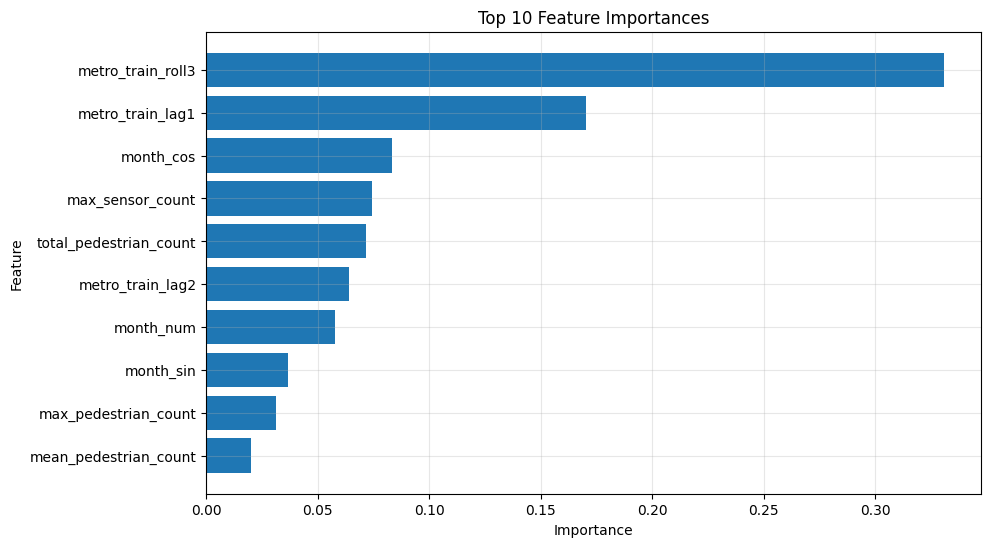

In [60]:
plot_df = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of Feature Importance

The factors that made the most contributions to the Random Forest model's predictions are shown in the feature significance plot. The rolling average of metro train patronage (`metro_train_roll3`), which is the most important characteristic, is followed by lag features like `metro_train_lag1` and `metro_train_lag2`. This suggests that predicting future transportation consumption heavily relies on past demand. Additionally, temporal features like `month_sin`, `month_cos`, and `month_num` have considerable importance, indicating that patronage levels are influenced by seasonal patterns.

Furthermore, the model incorporates pedestrian-related features like `total_pedestrian_count` and `max_sensor_count`, which validate that pedestrian activity is a significant stand-in for urban mobility and transportation demand. They are less significant than lag features, though, suggesting that historical transit demand is still the most reliable indicator.

In general, this analysis shows that the most important time-series features are rolling averages and lags, pedestrian activity offers helpful additional data and that demand is somewhat impacted by seasonality.

In [61]:
print("Average monthly metro train patronage:", round(df["metro_train"].mean(), 2))
print("Highest monthly metro train patronage:", round(df["metro_train"].max(), 2))
print("Lowest monthly metro train patronage:", round(df["metro_train"].min(), 2))
print("Average monthly total pedestrian count:", round(df["total_pedestrian_count"].mean(), 2))

Average monthly metro train patronage: 15575999.96
Highest monthly metro train patronage: 17994138
Lowest monthly metro train patronage: 13379440
Average monthly total pedestrian count: 24648093.78


In [62]:
corr_cols = [
    "metro_train",
    "total_pedestrian_count",
    "mean_pedestrian_count",
    "max_pedestrian_count",
    "weekend_share",
    "metro_train_lag1",
    "metro_train_lag2",
    "metro_train_roll3"
]

corr_matrix = df[corr_cols].corr()
corr_matrix.round(2)

,metro_train,total_pedestrian_count,mean_pedestrian_count,max_pedestrian_count,weekend_share,metro_train_lag1,metro_train_lag2,metro_train_roll3
metro_train,1.00,0.38,0.29,0.23,0.02,0.05,0.04,0.61
total_pedestrian_count,0.38,1.00,0.95,0.81,-0.06,-0.20,-0.19,-0.01
mean_pedestrian_count,0.29,0.95,1.00,0.87,-0.02,-0.15,-0.32,-0.11
max_pedestrian_count,0.23,0.81,0.87,1.00,-0.03,-0.24,-0.39,-0.23
weekend_share,0.02,-0.06,-0.02,-0.03,1.00,0.27,-0.50,-0.13
metro_train_lag1,0.05,-0.20,-0.15,-0.24,0.27,1.00,0.01,0.57
metro_train_lag2,0.04,-0.19,-0.32,-0.39,-0.50,0.01,1.00,0.61
metro_train_roll3,0.61,-0.01,-0.11,-0.23,-0.13,0.57,0.61,1.00


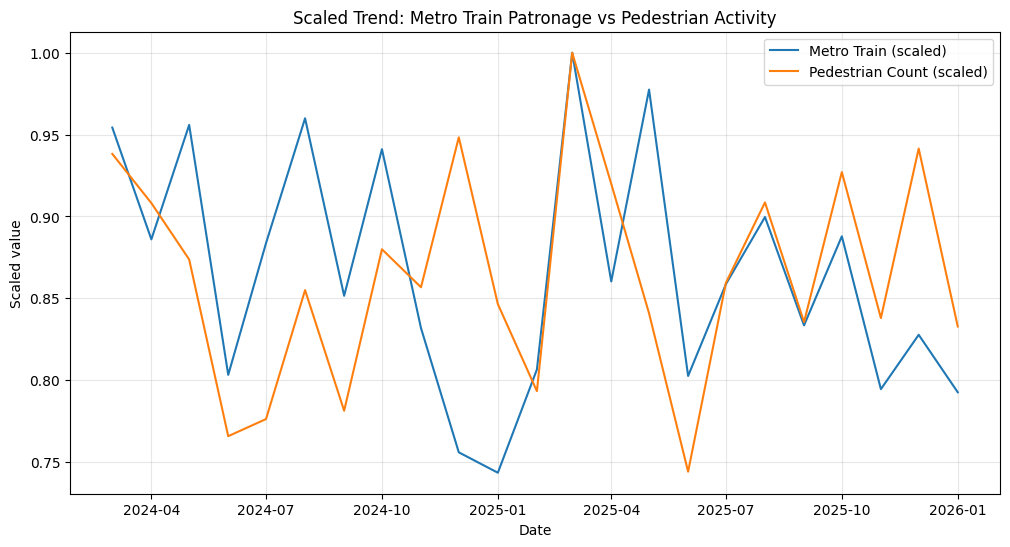

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["metro_train"] / df["metro_train"].max(), label="Metro Train (scaled)")
plt.plot(df["date"], df["total_pedestrian_count"] / df["total_pedestrian_count"].max(), label="Pedestrian Count (scaled)")

plt.title("Scaled Trend: Metro Train Patronage vs Pedestrian Activity")
plt.xlabel("Date")
plt.ylabel("Scaled value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Trend Comparison: Pedestrian Activity vs. Metro Train Patronage

This plot compares the scaled values of metro train patronage and total pedestrian counts over time. By scaling both series, it becomes easier to visually compare their patterns and trends despite differences in magnitude. The plot shows that both series follow a broadly similar trend over time, with peaks and troughs occurring at similar periods. This suggests a positive relationship between pedestrian activity and public transport demand.

However, the alignment is not perfect. There are periods where pedestrian activity increases while train patronage does not rise proportionally. This indicates that while pedestrian counts are a useful proxy for urban movement, they do not fully capture all factors influencing transport demand.

Weather, seasonal travel habits, and remote work schedules are a few more variables that might be important. The idea that pedestrian activity is a significant but incomplete predictor of public transport demand is generally supported by this visualization.

### Conclusion


For this project, I created a basic forecasting model that uses time-series features and pedestrian movement data to predict monthly metro train patronage. Cleaning and merging real-world datasets, converting high-frequency pedestrian sensor data into useful monthly characteristics, and creating lag-based and temporal variables to record past demand trends were all steps in the process. To determine their predictive performance, a number of models were trained and assessed, including a Random Forest model, Ridge Regression, and a naive baseline.

Ridge Regression achieved the lowest error across all evaluation metrics and yielded the most accurate and consistent results among the tested models. This result shows that a simpler linear model is better at generalizing patterns without overfitting, especially considering the tiny size of the dataset. Due to the small number of observations available for training, the Random Forest model did not beat Ridge Regression even though it was able to capture some non-linear correlations.

The findings also show that the most important factor in predicting future patronage is previous transit demand, especially lagged values and rolling averages. Although pedestrian activity characteristics added context about general urban movement to the model, their impact was not as great as that of the time-series features. Although it does not completely account for all fluctuations in transportation demand, the trend analysis also indicates that pedestrian activity generally follows a similar pattern to metro train patronage, supporting its usage as a proxy for city activity.

Overall, this experiment demonstrates that, particularly when dealing with limited data, correctly designed features and suitable model selection are more crucial than model complexity. The model created here offers a solid foundation for forecasting transportation demand. It can be enhanced by adding more data sources, like weather or event data, expanding the modeling approach to include multiple modes of transportation, and using more sophisticated methods when bigger datasets become accessible.